In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.datasets import make_blobs

In [10]:
X, _ = make_blobs(
    n_samples=400,
    centers=5,
    cluster_std=1.2,
    random_state=42
)

In [11]:
bandwidth = estimate_bandwidth(
    X,
    quantile=0.2,
    n_samples=len(X)
)

In [12]:
meanshift_model = MeanShift(
    bandwidth=bandwidth,
    bin_seeding=True
)

meanshift_model.fit(X)

MeanShift(bandwidth=3.6093413883900816, bin_seeding=True)

In [13]:
labels = meanshift_model.labels_

cluster_centers = meanshift_model.cluster_centers_

num_clusters = len(np.unique(labels))

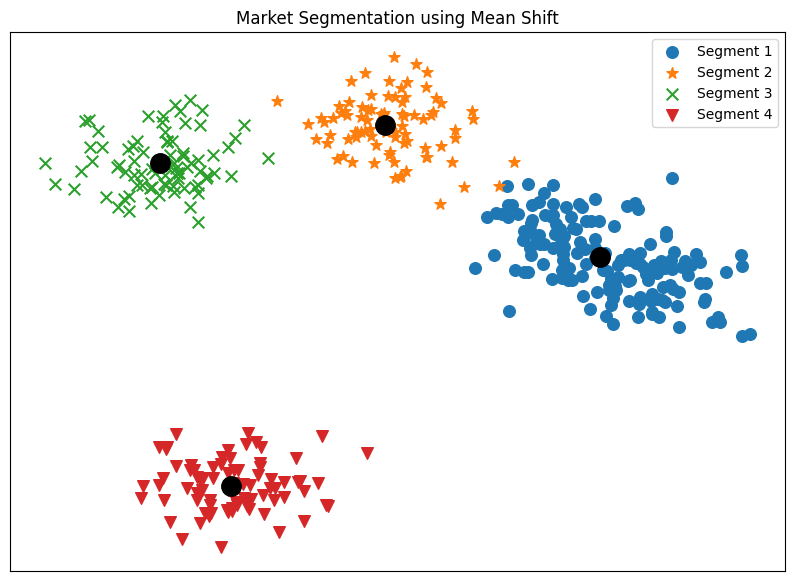

In [14]:
plt.figure(figsize=(10, 7))

markers = "o*xvsd"

for i, marker in zip(range(num_clusters), markers):

    plt.scatter(
        X[labels == i, 0],
        X[labels == i, 1],
        marker=marker,
        s=70,
        label="Segment " + str(i + 1)
    )

    center = cluster_centers[i]

    plt.plot(
        center[0],
        center[1],
        marker="o",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=14
    )

plt.title("Market Segmentation using Mean Shift")

plt.legend()

plt.xticks(())
plt.yticks(())

plt.show()